In [1]:
# This walkthrough follows https://www.machinelearningplus.com/machine-learning/portfolio-optimization-python-example/
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
%matplotlib inline

/Users/erikdies/Envs/base39/lib/python3.9/site-packages/requests/__init__.py:102: RequestsDependencyWarning: urllib3 (1.26.7) or chardet (5.0.0)/charset_normalizer (2.0.6) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({})/charset_normalizer ({}) doesn't match a supported "


The calculated value of pi: 3.1532


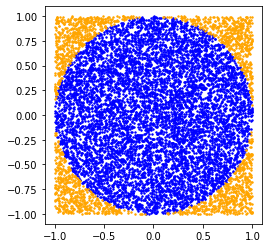

In [2]:
# Simple Monte Carlo Simulation
# Simulate Pi
N = 10_000

points = 2*np.random.rand(N, 2)-1

circleX, circleY, outsideX, outsideY = [], [], [], []
inside, outside = 0, 0
for x, y in points:
    if np.sqrt(x**2 + y**2) <= 1:
        inside +=1
        circleX.append(x)
        circleY.append(y)
    else:
        outside +=1
        outsideX.append(x)
        outsideY.append(y)
        
print("The calculated value of pi: {}".format(4*inside/(inside+outside)))
plt.axes().set_aspect('equal')
plt.scatter(circleX, circleY, 2, 'b')
plt.scatter(outsideX, outsideY, 2, 'orange')

In [3]:
# You are hitting yahoo for real data, this may hang if you run it many times
# you may be running into free API rate limits.
df = yf.download(['AAPL', 'META', 'GOOGL', 'AMZN'], start='2015-01-01', end='2019-12-31')
df.head()

[*********************100%***********************]  4 of 4 completed


Adj Close                                     Close            
                 AAPL     AMZN      GOOGL       META       AAPL     AMZN   
Date                                                                       
2015-01-02  24.565699  15.4260  26.477501  78.449997  27.332500  15.4260  \
2015-01-05  23.873650  15.1095  25.973000  77.190002  26.562500  15.1095   
2015-01-06  23.875893  14.7645  25.332001  76.150002  26.565001  14.7645   
2015-01-07  24.210680  14.9210  25.257500  76.150002  26.937500  14.9210   
2015-01-08  25.140907  15.0230  25.345501  78.180000  27.972500  15.0230   

                                       High           ...        Low   
                GOOGL       META       AAPL     AMZN  ...      GOOGL   
Date                                                  ...              
2015-01-02  26.477501  78.449997  27.860001  15.7375  ...  26.393999  \
2015-01-05  25.973000  77.190002  27.162500  15.4190  ...  25.887501   
2015-01-06  25.332001  76.150002  26.857500  15.1500  ...  25.277500   
2015-01-07  25.257500  76.150002  27.049999  15.0640  ...  25.182501   
2015-01-08  25.345501  78.180000  28.037500  15.1570  ...  24.750999   

                            Open                                    Volume   
                 META       AAPL     AMZN      GOOGL       META       AAPL   
Date                                                                         
2015-01-02  77.699997  27.847500  15.6290  26.629999  78.580002  212818400  \
2015-01-05  76.860001  27.072500  15.3505  26.357500  77.980003  257142000   
2015-01-06  75.360001  26.635000  15.1120  26.025000  77.230003  263188400   
2015-01-07  75.820000  26.799999  14.8750  25.547501  76.760002  160423600   
2015-01-08  76.080002  27.307501  15.0160  25.075500  76.739998  237458000   

                                          
                AMZN     GOOGL      META  
Date                                      
2015-01-02  55664000  26480000  18177500  
2015-01-05  55484000  41182000  26452200  
2015-01-06  70380000  54456000  27399300  
2015-01-07  52806000  46918000  22045300  
2015-01-08  61768000  73054000  23961000  

[5 rows x 24 columns]

,AAPL,AMZN,GOOGL,META
Date,,,,
2015-01-02,24.565699,15.4260,26.477501,78.449997
2015-01-05,23.873650,15.1095,25.973000,77.190002
2015-01-06,23.875893,14.7645,25.332001,76.150002
2015-01-07,24.210680,14.9210,25.257500,76.150002
2015-01-08,25.140907,15.0230,25.345501,78.180000


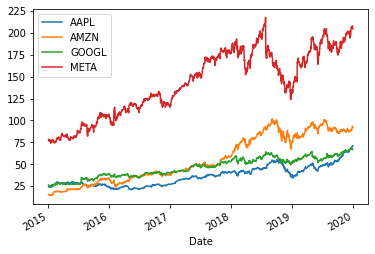

In [57]:
df_close = df['Adj Close']
df_close.plot()
df_close.head()
#df_close = df_close[["AAPL", "AMZN", "GOOGL"]]


In [58]:
# Covariance matrix
cov_matrix = df_close.pct_change().apply(lambda x: np.log(1+x)).cov()
cov_matrix

,AAPL,AMZN,GOOGL,META
AAPL,0.000246,0.000142,0.000122,0.000129
AMZN,0.000142,0.000334,0.000176,0.000187
GOOGL,0.000122,0.000176,0.000222,0.000161
META,0.000129,0.000187,0.000161,0.000320


In [59]:
# Correlation matrix
corr_matrix = df_close.pct_change().apply(lambda x: np.log(1+x)).corr()
corr_matrix

,AAPL,AMZN,GOOGL,META
AAPL,1.000000,0.496661,0.524875,0.459150
AMZN,0.496661,1.000000,0.647941,0.571207
GOOGL,0.524875,0.647941,1.000000,0.605846
META,0.459150,0.571207,0.605846,1.000000


In [62]:
# w = {'AAPL': 0.1, 'META': 0.2, 'GOOGL': 0.5, 'AMZN': 0.2}
# Change this to a computation so that tickers aren't hardcoded
weights = np.random.random(len(df_close.columns))
weights = weights/weights.sum()
w = dict(zip(df_close.columns, weights))
print(w)
print(sum(w.values()))
assert(sum(w.values()) == 1)
port_var = cov_matrix.mul(w, axis=0).mul(w, axis=1).sum().sum()
port_var

{'AAPL': 0.25582328602378057, 'AMZN': 0.3394881217675133, 'GOOGL': 0.09834342621625371, 'META': 0.30634516599245254}
1.0


0.00019805071595424366

In [63]:
# Yearly returns for individual companies
ind_er = df_close.resample('Y').last().pct_change().mean()
ind_er

AAPL     0.357854
AMZN     0.295745
GOOGL    0.155478
META     0.233810
dtype: float64

In [64]:
# Volatility is given by the annual standard deviation.
# We multiply by 250 because there are 250 trading days in a year.
ann_sd = df_close.pct_change().apply(lambda x: np.log(1+x)).std().apply(lambda x: x*np.sqrt(250))
ann_sd

AAPL     0.247871
AMZN     0.288770
GOOGL    0.235375
META     0.282853
dtype: float64

In [65]:
# Creating a table for visualising returns and volatility of assets
assets = pd.concat([ind_er, ann_sd], axis=1) 
assets.columns = ['Returns', 'Volatility']
assets

,Returns,Volatility
AAPL,0.357854,0.247871
AMZN,0.295745,0.288770
GOOGL,0.155478,0.235375
META,0.233810,0.282853


In [66]:
# Create some lists to capture the paramters we compute, not all currently used

p_ret = [] # Define an empty array for portfolio returns
p_vol = [] # Define an empty array for portfolio volatility
p_weights = [] # Define an empty array for asset weights

num_assets = len(df_close.columns)
N = 10000

for portfolio in range(N):
    weights = np.random.random(num_assets)
    weights = weights/np.sum(weights)
    p_weights.append(weights)
    returns = np.dot(weights, ind_er) # Returns are the product of individual expected returns of asset and its 
                                      # weights 
    p_ret.append(returns)
    _var = cov_matrix.mul(weights, axis=0).mul(weights, axis=1).sum().sum()# Portfolio Variance
    _sd = np.sqrt(_var) # Daily standard deviation
    _ann_sd = _sd*np.sqrt(250) # Annual standard deviation = volatility
    p_vol.append(_ann_sd)

In [67]:
data = {'Returns':p_ret, 'Volatility':p_vol}

for counter, symbol in enumerate(df_close.columns.tolist()):
    #print(counter, symbol)
    data[symbol+' weight'] = [w[counter] for w in p_weights]

portfolios  = pd.DataFrame(data)
portfolios.head() # Dataframe of the 10000 portfolios created

,Returns,Volatility,AAPL weight,AMZN weight,GOOGL weight,META weight
0,0.257029,0.219419,0.203913,0.370710,0.319607,0.105770
1,0.305531,0.220215,0.436319,0.348791,0.051119,0.163771
2,0.203194,0.221028,0.053877,0.189866,0.626290,0.129968
3,0.259800,0.221636,0.178809,0.318240,0.202985,0.299966
4,0.266785,0.210816,0.337606,0.213756,0.282672,0.165966


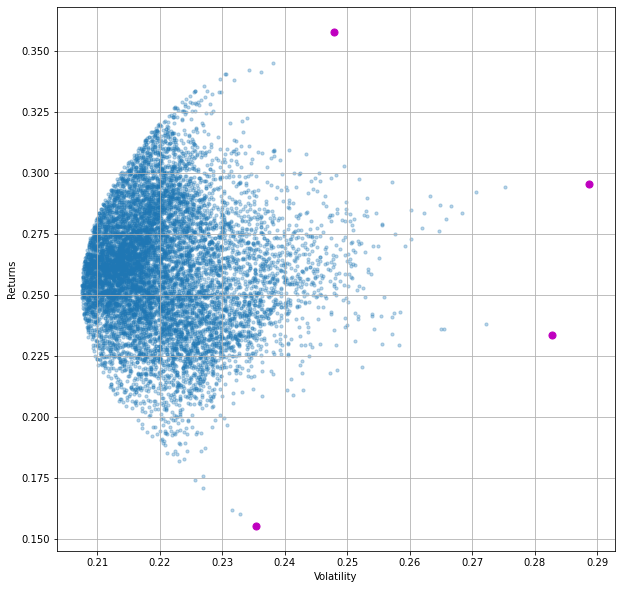

In [68]:
portfolios.plot.scatter(x='Volatility', y='Returns', marker='o', s=10, alpha=0.3, grid=True, figsize=[10,10])
plt.scatter(assets["Volatility"], assets["Returns"], marker='o', s=50, color='m')

In [14]:
min_vol_port = portfolios.iloc[portfolios['Volatility'].idxmin()]
# idxmin() gives us the minimum value in the column specified.                               
min_vol_port

Returns         0.252870
Volatility      0.207545
AAPL weight     0.391211
AMZN weight     0.050660
GOOGL weight    0.416240
META weight     0.141889
Name: 9644, dtype: float64

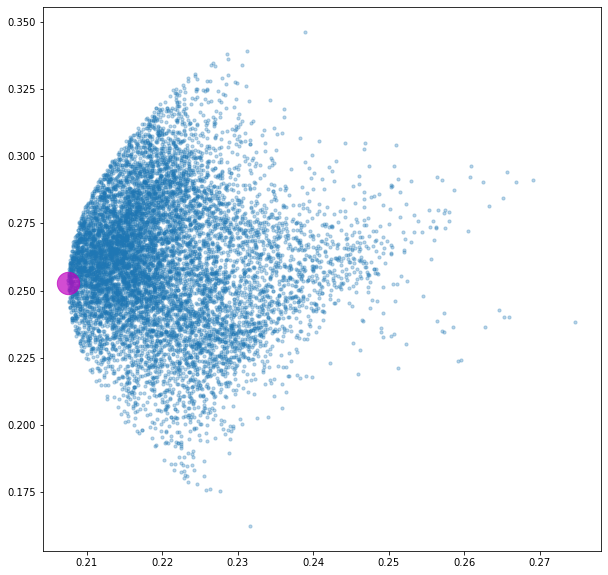

In [15]:
plt.subplots(figsize=[10,10])
plt.scatter(portfolios['Volatility'], portfolios['Returns'],marker='o', s=10, alpha=0.3)
plt.scatter(min_vol_port[1], min_vol_port[0], color='m', marker='o', s=500, alpha=0.7)

## The optimal risky portfolio is the one with the highest Sharpe ratio.
$$ \text{Sharpe Ratio} = \frac{R_p - R_f}{\sigma_p}$$
Where $R_p$ is return on portfolio, $\sigma_p$ is risk of the portfolio, and $R_f$ is the risk-free rate

In [16]:
# Finding the optimal portfolio
rf = 0.01 # risk free rate of 1%

# Here we are computing the sharpe ratio of all the points, then taking the portfolio with the maximized
# ratio.  The slope of the line through the risk-free asset and the portfolio gives the sharpe ratio,
# so if we maximize the ratio we find the tangent line slope and tangent line point.  Note that this
# computation requires that we probabalistically generated a portfolio somewhat close to the optimal one.
optimal_risky_port = portfolios.iloc[((portfolios['Returns']-rf)/portfolios['Volatility']).idxmax()]
optimal_risky_port

Returns         0.338364
Volatility      0.228626
AAPL weight     0.775444
AMZN weight     0.159224
GOOGL weight    0.019106
META weight     0.046226
Name: 2746, dtype: float64

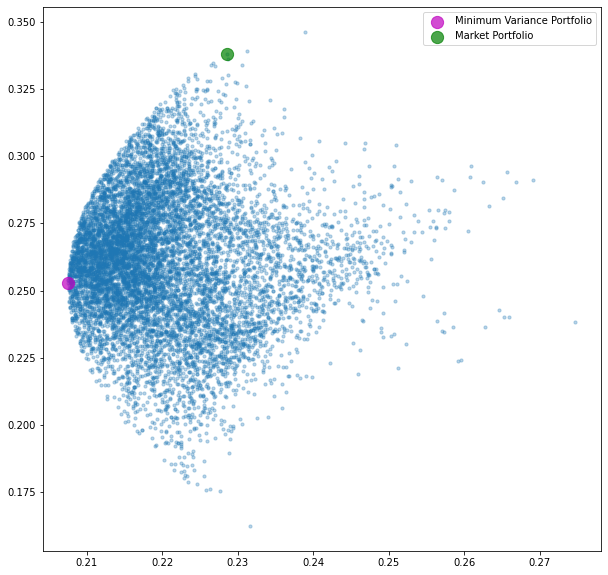

In [23]:
plt.subplots(figsize=(10, 10))
plt.scatter(portfolios['Volatility'], portfolios['Returns'],marker='o', s=10, alpha=0.3)
plt.scatter(min_vol_port[1], min_vol_port[0], color='m', marker='o', s=150, alpha=0.7, label="Minimum Variance Portfolio")
plt.scatter(optimal_risky_port[1], optimal_risky_port[0], color='g', marker='o', s=150, alpha=0.7, label="Market Portfolio")
plt.legend(loc='upper right')

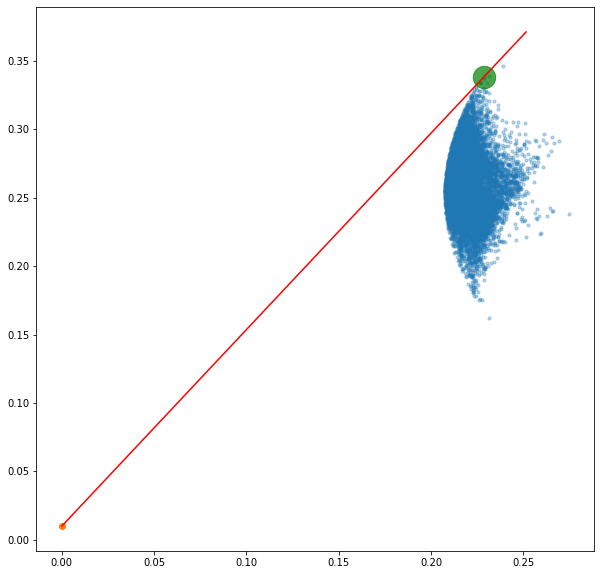

In [18]:
plt.subplots(figsize=(10, 10))
plt.scatter(portfolios['Volatility'], portfolios['Returns'],marker='o', s=10, alpha=0.3)
plt.scatter(optimal_risky_port[1], optimal_risky_port[0], color='g', marker='o', s=500, alpha=0.7)
plt.scatter(0, rf)
X = np.linspace(0, optimal_risky_port[1]*1.1, 1000)
Y = lambda x: x*(optimal_risky_port[0]-rf)/(optimal_risky_port[1]) + rf
plt.plot(X, Y(X), 'r-')